# Perdendo Dinheiro na Bolsa de Valores Usando Física e Redes Neurais

- PET - Física
- Petiana: Ylana Karolina Santos Lopes
- Data: 10 de Abril de 2026

$\quad$ O objetivo deste `Notebook` é introduzir de forma prática a Econofísica, analisando o comportamento de uma ação real do mercado (Petrobras - PETR4). Vamos aplicar ferramentas inspiradas na física para limpar o gráfico de preços, separando as tendências mais fortes e consistentes das flutuações rápidas e caóticas que acontecem no dia a dia.

$\quad$ Ao longo do texto, trataremos o mercado financeiro como um sistema físico dinâmico. Mostraremos como pegar um gráfico complexo e quebrá-lo em ondas mais simples (usando um algoritmo chamado CEEMDAN), e como calcular a energia dessas ondas. Por fim, vamos usar uma Rede Neural do tipo Long Short Time Memory para ler as informações extraídas dos dados e tentar prever os próximos movimentos.

$\quad$ Tudo será construído passo a passo, de forma que não é necessário nenhum conhecimento prévio em economia ou mercado financeiro para acompanhar o raciocínio.

Com isso, o `Notebook` será organizado da seguinte forma:

    1. Introdução;
    2. A Física do Sinal;
    3. Treinamento da LSTM;
    4. Resultados e Limitações;
    5. Conclusão.
    
$\quad$ A ideia primária deste trabalho é ser um primeiro contato com a área de econofísica. Caso o leitor tenha interesse em treinamento de redes neurais, indico a leitura dos `Notebooks`: *Classificação espectral estelar usando Machine Learning* e *Rede convolucional para Redução de Ruídos em Imagens de Galáxias*.
:)

## Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from PyEMD import CEEMDAN
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


## Informações sobre as bibliotecas

In [2]:
%load_ext version_information
%version_information numpy, pandas, yfinance, PyEMD, scipy, matplotlib, torch, sklearn

Software,Version
Python,3.11.8 64bit [MSC v.1916 64 bit (AMD64)]
IPython,8.20.0
OS,Windows 10 10.0.26200 SP0
numpy,1.26.4
pandas,2.1.4
yfinance,1.2.0
PyEMD,1.9.0
scipy,1.17.1
matplotlib,3.8.0
torch,2.7.0+cpu


## 1. Introdução

$\quad$ A tentativa de descrever o comportamento dos mercados financeiros através de leis matemáticas rigorosas não é um fenômeno recente. O marco inicial dessa jornada ocorreu em 1900, quando o matemático francês Louis Bachelier apresentou sua tese "Teoria da Especulação", onde formalizou pela primeira vez a ideia de que os preços seguem um "passeio aleatório" (_random walk_), antecipando em cinco anos a descrição física do movimento browniano feita por Albert Einstein. **[1]** Embora o trabalho de Bachelier tenha permanecido marginal por décadas, ele estabeleceu a premissa fundamental de que a dinâmica dos preços pode ser modelada como um processo estocástico. **[1]** **[2]**

$\quad$ Somente na década de 1990 o termo Econofísica foi cunhado pelo físico Eugene Stanley, consolidando um campo interdisciplinar que aplica métodos e conceitos da física teórica (como escalas, fractais e caos) para investigar problemas econômicos e analisar grandes volumes de dados financeiros. **[3]** A Econofísica parte do princípio de que os mercados são sistemas complexos abertos, compostos por uma vasta quantidade de agentes (unidades) que interagem de forma não linear e sob mecanismos de feedback. **[1]** **[4]**

$\quad$ Um conceito central que desafiaremos neste estudo é a Hipótese do Mercado Eficiente (HME), que sustenta que os preços dos ativos incorporam instantaneamente todas as informações disponíveis. **[1]** **[5]** Segundo essa teoria, se o mercado for perfeitamente eficiente, as mudanças de preço tornam-se imprevisíveis a partir de séries históricas, onde o melhor palpite para o preço futuro é o preço atual. **[1]** Entretanto, a Econofísica argumenta que a presença de dependências temporais e comportamentos não lineares pode permitir a detecção de estruturas onde a teoria tradicional vê apenas ruído aleatório. **[4]**

$\quad$ Neste `Notebook`, trataremos o mercado financeiro não apenas como um local de trocas comerciais, mas como um sistema físico dinâmico complexo. Sob essa perspectiva, as flutuações de preços de uma ação como a Petrobras (PETR4) deixam de ser vistas apenas como números contábeis e passam a ser comparadas ao comportamento de partículas em um fluido ou ao fluxo de energia em sistemas termodinâmicos, onde o lucro é análogo ao calor e o capital à energia. **[3]** O objetivo é analisar a PETR4 através de sua dinâmica subjacente, tratando o mercado como o comportamento macroscópico de um sistema dinâmico em constante evolução. **[1]** **[4]**

$\quad$ Dessa forma, nosso primeiro passo é baixar os dados. Aqui estamos usando a biblioteca `yfinance`que dá acesso aos dados do mercado financeiro disponibilizados pela Yahoo Finance. Os dados escolhidos são os do ativo da Petrobras (PETR4) entre 01/01/2020 e 01/01/2024.

In [3]:
# Obter e Limpar Dados (PETR4)
ticker = 'PETR4.SA'
df = yf.download(ticker, start='2020-01-01', end='2024-01-01')
prices = df['Close'].dropna().values.flatten().astype(np.float64)
t = np.arange(len(prices))

[*********************100%***********************]  1 of 1 completed


$\quad$ Uma vez obtidos os dados da PETR4, deparamo-nos com o desafio central desse trabalho: a natureza do sinal. Diferente de sistemas físicos ideais, o mercado financeiro é um sistema complexo aberto, onde diversar unidades interagem de forma não linear e com mecanismos de feedback. Além disso, séries temporais de preços são fundamentalmente não estacionárias, o que significa que suas propriedades estatísticas, como a média e a volatilidade (desvio padrão), mudam ao longo do tempo.

## 2. A Física do Sinal

$\quad$ Tratar um ativo como um sistema físico significa entender que cada oscilação de preço carrega uma assinatura energética própria. O desafio é que o sinal financeiro é inerentemente ruidoso. Nele, tendências de longo prazo se perdem em meio a distorções de curtíssimo prazo que mascaram a verdadeira inércia do mercado.**[1]** **[3]** É preciso, portanto, separar o sinal do ruído para revelar a dinâmica que realmente governa o movimento. Métodos tradicionais como a Análise de Fourier, falham ao lidar com esses dados pois pressupõem que o sinal seja composto por frequências constantes e estacionárias. Para superar essa limitação, utilizamos o algoritmo CEEMDAN (_Complete Ensemble Empirical Mode Decomposition with Adaptive Noise_). **[6]** Escolhemos esta ferramenta por ela ser especificamente desenhada para dados ruidosos e não lineares, permitindo decompor uma série complexa em componentes oscilatórios mais simples e de diferentes escalas temporais, sem a necessidade de uma base funcional pré-fixada.

In [4]:
# Decomposição CEEMDAN 
ceemdan = CEEMDAN(trials=100, epsilon=0.005)
imfs = ceemdan(prices, t)
num_imfs = imfs.shape[0]

$\quad$ O resultado da aplicação do CEEMDAN é a extração de uma série de ondas chamadas Funções de Modo Intrínseco (IMFs). **[6]** Na perspectiva da física, as IMFs resultantes da decomposição funcionam como os modos fundamentais de vibração subjacentes ao preço da PETR4. Elas são extraídas diretamente dos dados, sem a necessidade de funções matemáticas pré-fixadas ou bases funcionais rígidas. Diferente dos métodos tradicionais de Fourier, as IMFs permitem que tanto a amplitude quanto a fase variem de forma dinâmica ao longo do tempo.

$\quad$ Para serem fisicamente consistentes, essas funções devem ser simétricas em relação à média local. Além disso, o número de pontos extremos e de cruzamentos pelo zero deve ser igual ou ter uma diferença máxima de um. O processo de extração remove a média do sinal em escalas de tempo definidas pelos próprios picos e vales dos dados. Isso garante uma análise local e adaptativa, ideal para a natureza não linear e não estacionária do mercado financeiro.

$\quad$ Matematicamente, o sinal original $S(t)$ (o preço da PETR4) é decomposto como:


$$S(t) = \sum_{i=1}^{n} IMF_i(t) + r_n(t)$$

onde $IMF_i(t)$ são as diversas escalas de oscilação extraídas (da mais rápida/ruído para a mais lenta/tendência). E $r_n(t)$ é o resíduo final, que representa a tendência geral de longo prazo do ativo. **[6]** Ao isolar esses componentes, podemos aplicar a física do sinal para analisar a energia e a volatilidade de cada modo individualmente.

$\quad$ A seguir, visualizamos a decomposição do preço original em suas diversas escalas temporais.

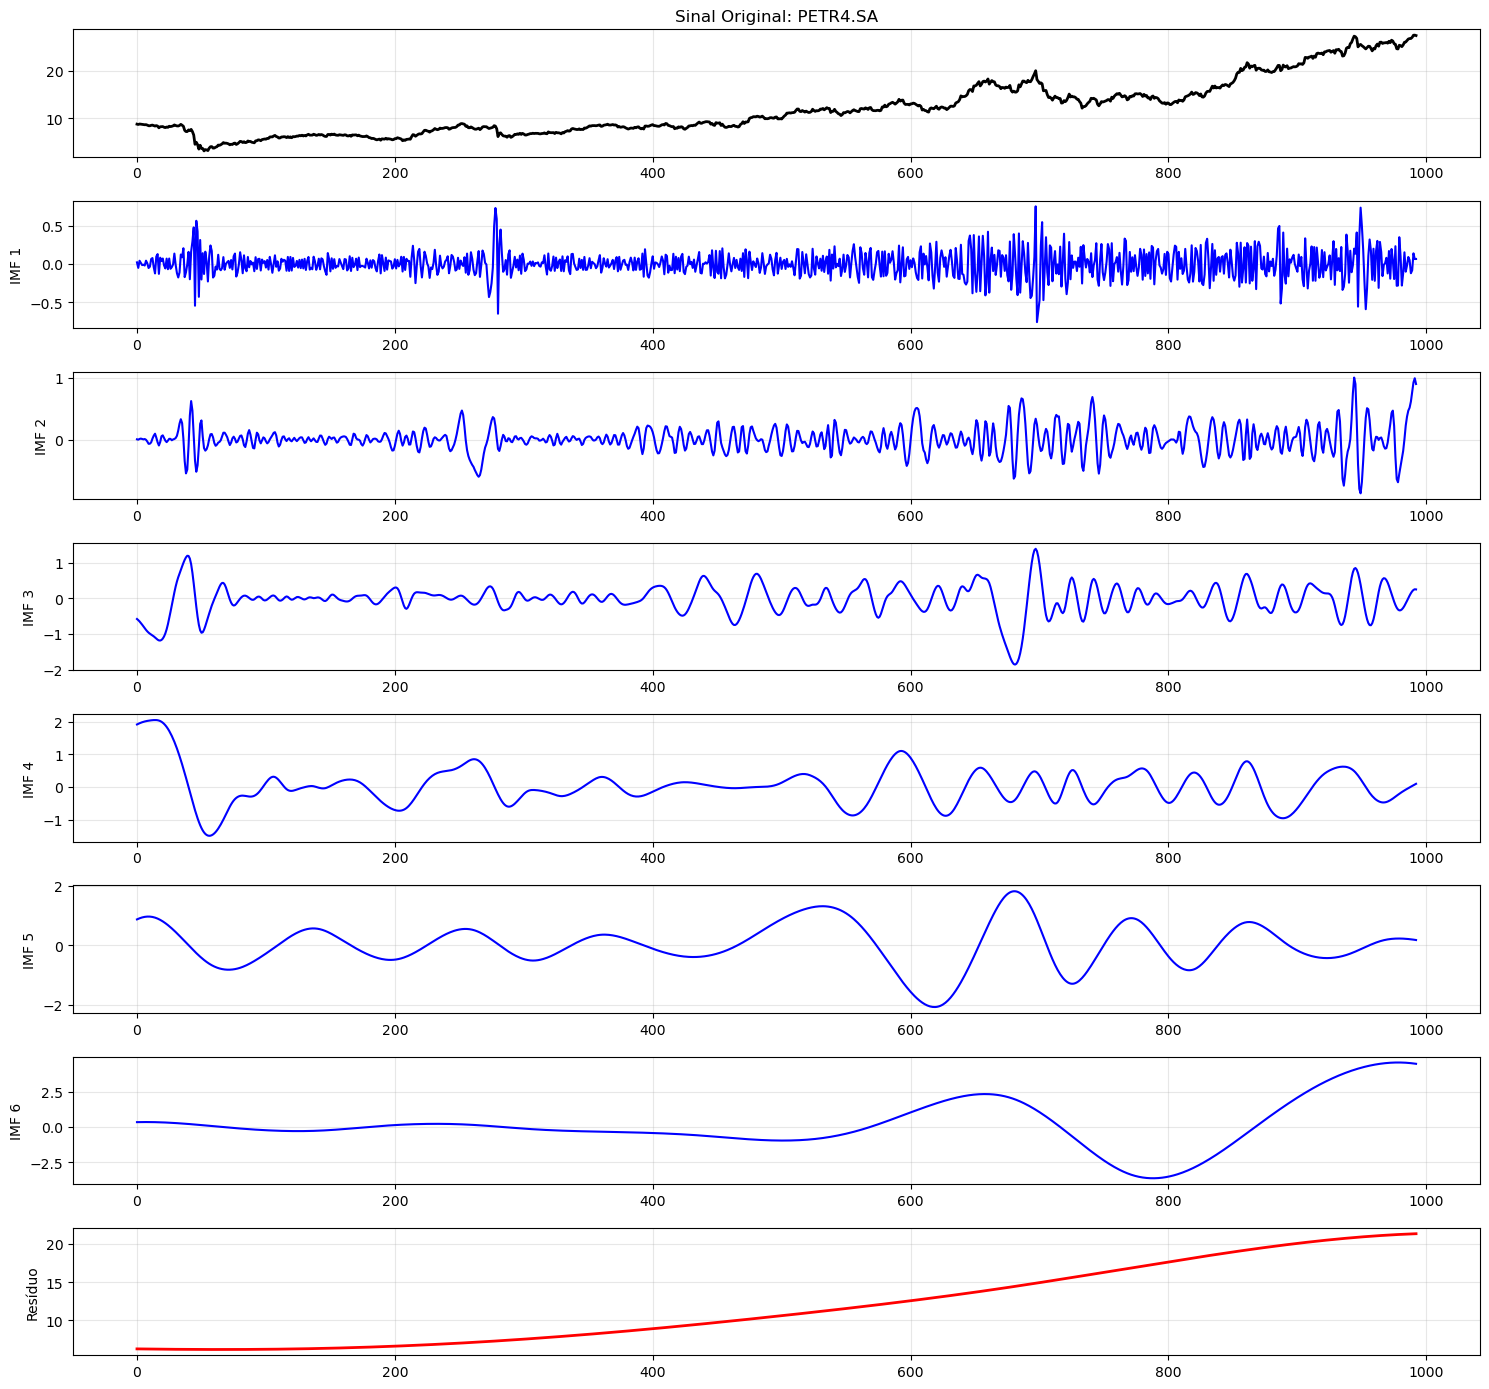

In [5]:
# Plotar todas as IMFs e o resíduo
plt.figure(figsize=(15, num_imfs * 2))
plt.subplot(num_imfs + 1, 1, 1)
plt.plot(t, prices, 'k', linewidth=2)
plt.title(f'Sinal Original: {ticker}')
plt.grid(True, alpha=0.3)

for i in range(num_imfs - 1):
    plt.subplot(num_imfs + 1, 1, i + 2)
    plt.plot(t, imfs[i], 'b')
    plt.ylabel(f'IMF {i+1}')
    plt.grid(True, alpha=0.3)

plt.subplot(num_imfs + 1, 1, num_imfs + 1)
plt.plot(t, imfs[-1], 'r', linewidth=2) # Última IMF é o resíduo
plt.ylabel('Resíduo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


$\quad$ Na prática, o CEEMDAN funciona como um banco de filtros no domínio da frequência. **[6]** **[7]**  Cada IMF captura processos cíclicos dentro de uma faixa específica de tempo, desde o ruído de alta frequência até as tendências de longo prazo. Uma vantagem crucial é que esse sistema não exige que a tendência geral do gráfico seja removida antes da análise. Assim, conseguimos isolar os componentes do sinal para identificar onde reside a energia do sistema. **[7]**

$\quad$ Com os modos fundamentais isolados, aplicamos a Transformada de Hilbert a cada IMF para construir um sinal analítico complexo. A partir desse sinal, extraímos a frequência instantânea, definida matematicamente como a derivada temporal da função de fase da oscilação. Ao contrário da análise de Fourier tradicional, que assume frequências constantes e globais, a frequência instantânea permite descrever as mudanças locais e dinâmicas no ritmo das flutuações da PETR4, capturando a essência de um sistema físico que é inerentemente não linear e não estacionário.

$\quad$ Essa análise resulta no Espectro de Hilbert, um mapa que distribui a energia (quadrado da amplitude instantânea) através do plano tempo-frequência. **[6]** **[7]** No contexto deste problema, a amplitude de energia representa a intensidade de uma oscilação específica em um dado momento. Fisicamente, identificar onde a energia está concentrada nos permite separar o "sinal" real da "fricção" do sistema: as componentes que apresentam alta amplitude de energia em frequências mais baixas revelam as tendências robustas e persistentes do ativo. **[3]**  Por outro lado, oscilações com baixa energia e frequências erráticas são tratadas como ruído estocástico, permitindo que a filtragem física limpe o sinal antes que ele seja processado pela nossa rede neural LSTM. **[4]** 

$\quad$ Usando a biblioteca `SciPy`, temos como objetivo dessa etapa calcular a amplitude (energia) e a frequência instantânea de cada componente, permitindo mapear como a intensidade e a velocidade das oscilações da PETR4 evoluem ao longo do tempo.

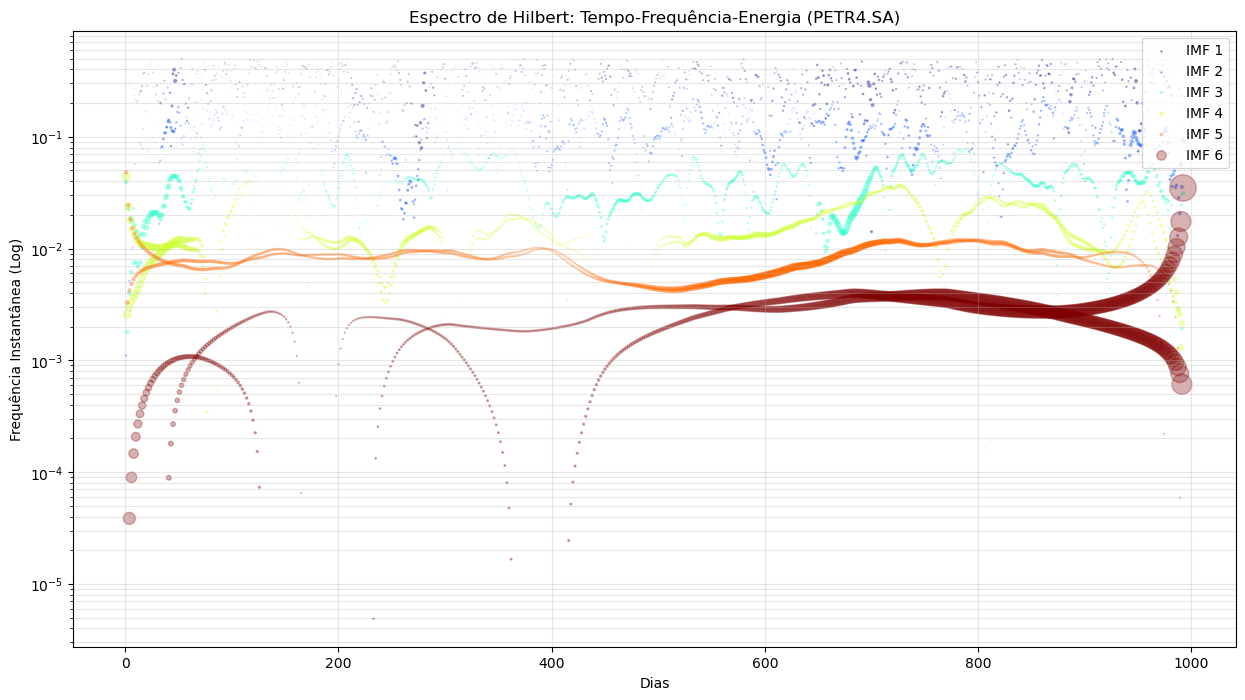

In [6]:
plt.figure(figsize=(15, 8))
colors = cm.jet(np.linspace(0, 1, num_imfs - 1))
mean_frequencies = []

# Loop calcula a transformada, plota o espectro e extrai as médias
for i in range(num_imfs - 1):
    # 1. Obtenção da Cinemática da Onda via Sinal Analítico Complexo
    analytic_signal = hilbert(imfs[i])
    amplitude = np.abs(analytic_signal)
    
    # Derivada da fase para encontrar a Frequência Instantânea
    phase = np.unwrap(np.angle(analytic_signal))
    frequency = np.diff(phase) / (2.0 * np.pi)
    
    # 2. Plot do Espectro de Hilbert (Tamanho do ponto = Energia da onda)
    energy = amplitude[1:]**2
    plt.scatter(t[1:], frequency, c=[colors[i]], s=energy * 5, alpha=0.3, label=f'IMF {i+1}')
    
    # 3. Guarda a Frequência Média para usar no Filtro Passa-Baixa
    valid_freqs = frequency[frequency > 0] # Remove ruído numérico espúrio
    if len(valid_freqs) > 0:
        mean_frequencies.append(np.mean(valid_freqs))
    else:
        mean_frequencies.append(0)

plt.yscale('log')
plt.title(f'Espectro de Hilbert: Tempo-Frequência-Energia ({ticker})')
plt.xlabel('Dias')
plt.ylabel('Frequência Instantânea (Log)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='upper right', markerscale=0.5)
plt.show()



$\quad$ O gráfico resultante é o Espectro de Hilbert, onde a dispersão dos pontos revela a densidade de energia em diferentes escalas temporais. Pontos maiores indicam momentos de maior volatilidade ou força direcional, servindo como critério físico para identificar quais componentes carregam a tendência principal do ativo. A junção do CEEMDAN com a análise espectral de Hilbert é chamada de Transformada de Hilbert-Huang (HHT). Através dela, utilizamos o Espectro de Hilbert como o argumento físico definitivo para estabelecer o cut-off (ponto de corte) do nosso filtro passa-baixas.

$\quad$ Um filtro passa-baixas é um operador que permite a passagem de sinais com frequências baixas — que representam as tendências macro e a inércia do mercado — enquanto atenua ou elimina as frequências altas, comumente associadas ao ruído estocástico de curtíssimo prazo.

$\quad$ No Espectro de Hilbert, observamos que as primeiras IMFs habitam zonas de frequências extremamente elevadas e possuem dispersão errática de energia. Elas são a "agitação térmica" do sistema. Ao identificar onde essa energia desordenada termina, isolamos o sinal inercial. O filtro, portanto, não é escolhido de forma arbitrária; ele é moldado pela própria dinâmica energética da PETR4, garantindo que apenas os ciclos com densidade de energia relevante sobrevivam para a etapa de modelagem. Neste caso, as IMFs 1 e 2 são descartadas como agitação térmica e o restante será considerado sinal.



--- Frequências Fundamentais (Modos Normais) ---
IMF 1: Frequência Média = 0.2933 ciclos/dia
IMF 2: Frequência Média = 0.1193 ciclos/dia
IMF 3: Frequência Média = 0.0402 ciclos/dia
IMF 4: Frequência Média = 0.0166 ciclos/dia
IMF 5: Frequência Média = 0.0082 ciclos/dia
IMF 6: Frequência Média = 0.0025 ciclos/dia


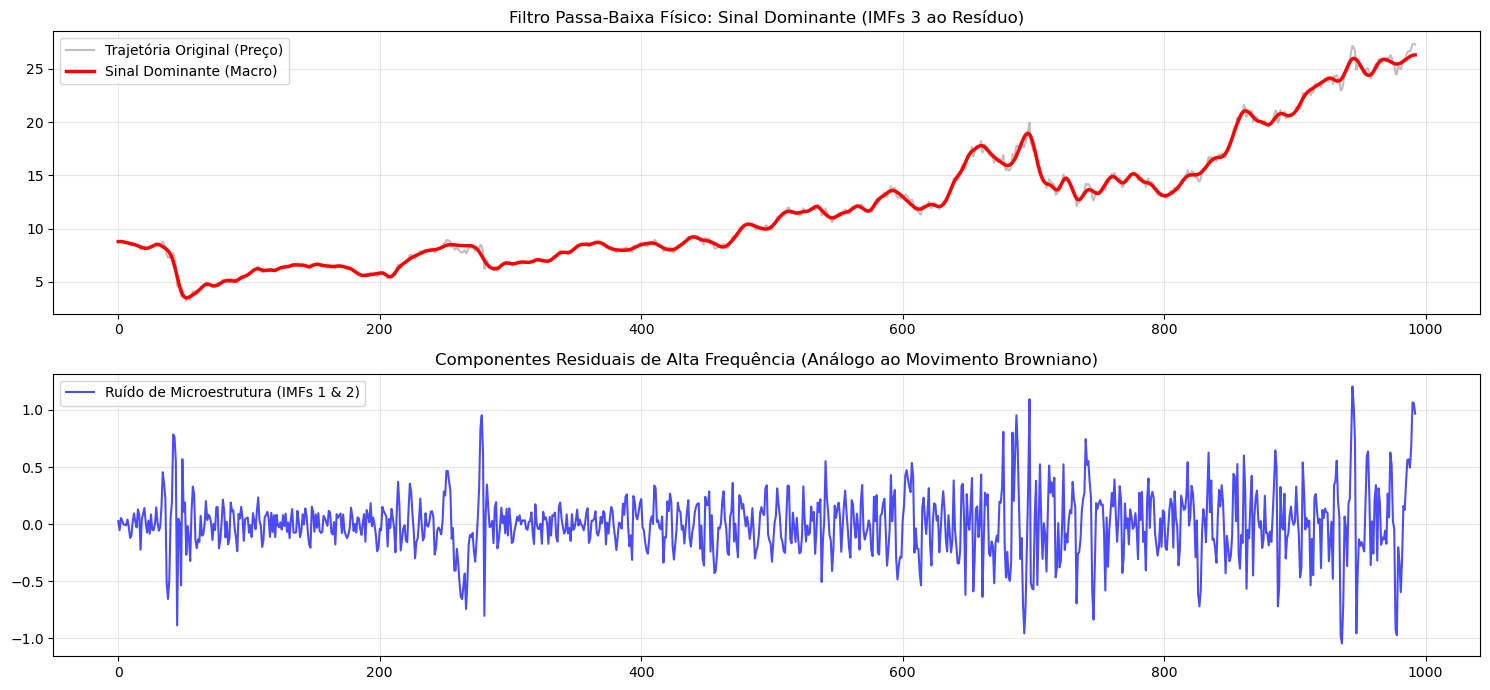

In [7]:
print(f"\n--- Frequências Fundamentais (Modos Normais) ---")
for i, f in enumerate(mean_frequencies):
    print(f"IMF {i+1}: Frequência Média = {f:.4f} ciclos/dia")

# IMFs de altíssima frequência são ruído de microestrutura.
cut_off_index = 2 # IMFs 1 e 2 serão tratadas como "agitação térmica"

# Reconstrução linear 
sinal_dominante = np.sum(imfs[cut_off_index:-1], axis=0) # O momento inercial real
ruido_residual = np.sum(imfs[:cut_off_index], axis=0)  # O ruído descartado
tendencia_macro = imfs[-1]

# Plotando o resultado do filtro
plt.figure(figsize=(15, 7))

# Plot Superior: O Sinal Limpo vs Original
plt.subplot(2, 1, 1)
plt.plot(t, prices, 'gray', alpha=0.5, label='Trajetória Original (Preço)')
plt.plot(t, sinal_dominante + tendencia_macro, 'r', linewidth=2.5, label='Sinal Dominante (Macro)')
plt.title(f'Filtro Passa-Baixa Físico: Sinal Dominante (IMFs {cut_off_index+1} ao Resíduo)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Inferior: O Ruído Descartado
plt.subplot(2, 1, 2)
plt.plot(t, ruido_residual, 'b', alpha=0.7, label='Ruído de Microestrutura (IMFs 1 & 2)')
plt.title('Componentes Residuais de Alta Frequência (Análogo ao Movimento Browniano)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

$\quad$ Ao observar os gráficos de filtragem, fica evidente que o sinal reconstruído a partir das frequências mais baixas engloba o movimento estrutural do ativo. Enquanto o preço original da Petrobras é bombardeado por flutuações erráticas, essa versão filtrada captura as reversões e os ciclos que realmente definem a trajetória da ação no longo prazo.

$\quad$ Retirar as ondas de altíssima frequência (o ruído de microestrutura) é um passo fundamental. Ao realizar essa limpeza, eliminamos o caos que forçaria a rede neural a buscar padrões em movimentos puramente aleatórios. Com o sinal ajustado, o modelo consegue identificar dependências temporais sólidas, entregando uma previsão que não se perde em sustos de curto prazo, mas se mantém aderente ao fluxo das grandes tendências.

$\quad$ Definida essa filtragem inicial, o próximo passo exige rigor físico. No mercado, as tendências raramente se movem em linhas retas; elas se comportam como ciclos superpostos a uma deriva direcional. Para capturar a dinâmica cíclica sem violar a matemática do modelo, isolamos o sinal dominante e extraímos dele a tendência macro (última IMF). Isso é crucial: pelas próprias definições do método, uma função precisa ser simétrica e cruzar o eixo zero para ser fisicamente consistente. Ao removermos a tendência monótona, garantimos que o sinal estrutural passe a oscilar em torno do zero, respeitando a natureza de uma IMF e preparando o terreno para a próxima transformação.

$\quad$ O objetivo técnico agora é extrair o envelope dessa onda perfeitamente centrada, ou seja, sua amplitude instantânea. Na física, essa medida representa a energia do sistema. Em vez de exigir que a rede preveja cada "ziguezague" imprevisível do preço, nós a treinamos para modelar a evolução dessa energia subjacente. É uma troca estratégica. Paramos de perseguir o ruído momentâneo para focar na força inercial que empurra o ciclo. Como essa curva de energia é muito mais suave, ela permite que a inteligência artificial entenda a vitalidade do movimento antes mesmo que ele mude de direção.

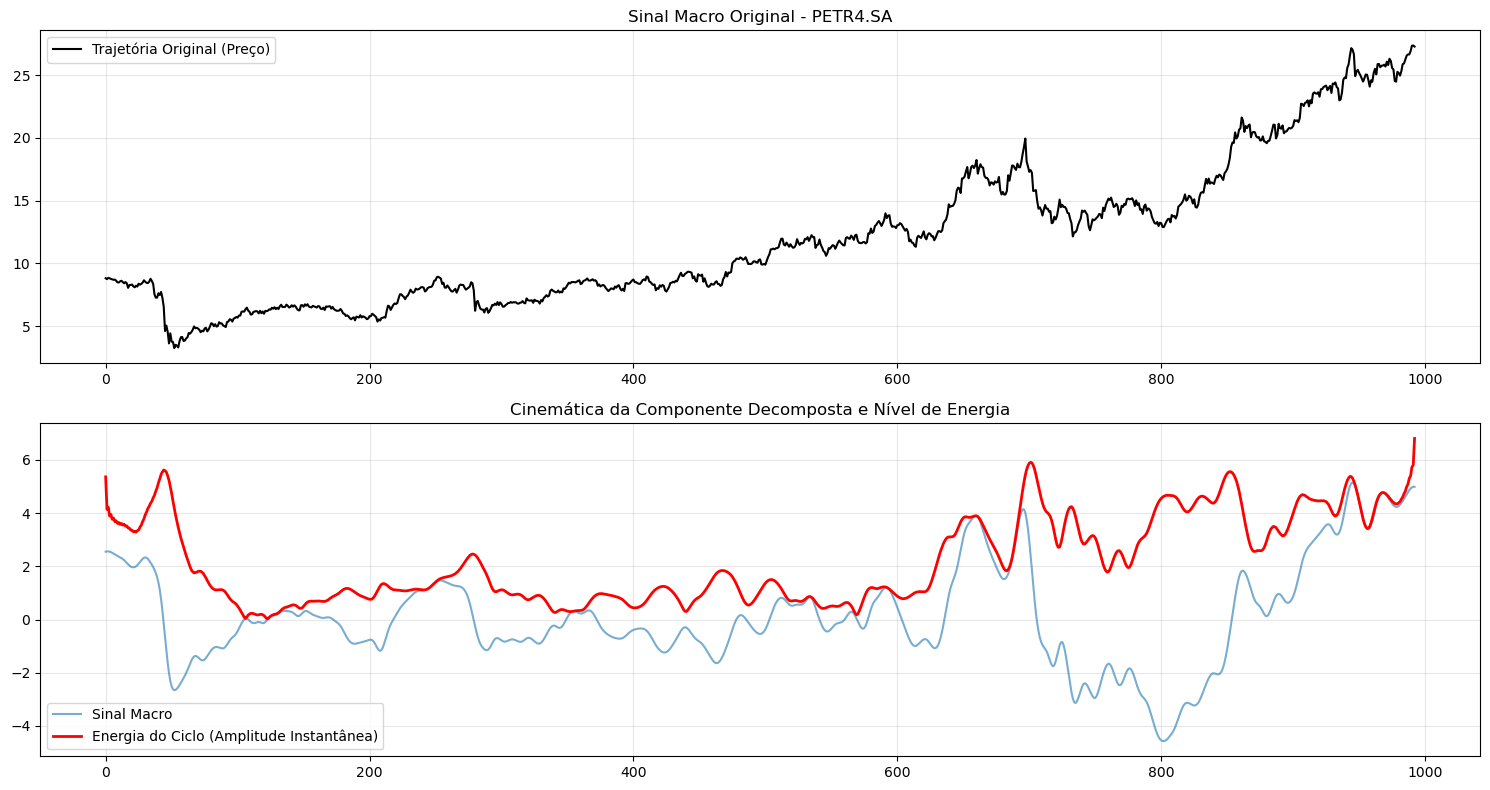

In [8]:
# No bloco anterior, definimos que o ruído termina na IMF 2 (índices 0 e 1).
# Vamos pegar o "sinal macro" (soma das IMFs) para modelar.

# A Transformada de Hilbert nos dá o envelope da onda (sua Energia/Amplitude atual)
amplitude_instantanea = np.abs(hilbert(sinal_dominante))

# Visualização: A Onda Isolada e sua Energia Cinética
plt.figure(figsize=(15, 8))

# Plot Superior: Preço Original para referência
plt.subplot(2, 1, 1)
plt.plot(t, prices, label='Trajetória Original (Preço)', color='black')
plt.title(f'Sinal Macro Original - {ticker}')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot Inferior: A onda pura e a curva de energia que a LSTM vai prever
plt.subplot(2, 1, 2)
plt.plot(t, sinal_dominante, label=f'Sinal Macro', alpha=0.6)
plt.plot(t, amplitude_instantanea, label='Energia do Ciclo (Amplitude Instantânea)', color='red', linewidth=2)
plt.title('Cinemática da Componente Decomposta e Nível de Energia')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

$\quad$ A comparação entre esse sinal estrutural limpo e sua amplitude instantânea revela a verdadeira anatomia do movimento. Enquanto a onda cruza os valores positivos e negativos, a linha vermelha define a estatura dessa oscilação em cada instante (sendo positiva por definição). Ela funciona como o esqueleto que sustenta o movimento. Observar as duas curvas juntas prova que o envelope está descrevendo a dinâmica real da onda, sem o risco de gerar distorções matemáticas causadas por um eixo deslocado. Nas extremidades do gráfico, porém, surgem distorções causadas pelo efeito de borda. Como a Transformada de Hilbert depende de dados futuros para calcular o envelope atual, a ausência dessas informações leva o algoritmo a extrapolar de forma imprecisa, revelando os primeiros sinal da limitação do modelo.

$\quad$ Apesar dessa vulnerabilidade nas pontas, para a rede neural, a mudança de foco da onda para a energia é o que separa o caos da previsibilidade. Tentar prever a onda original exigiria que o modelo acertasse o momento exato de cada inversão, o que é uma tarefa complexa e sujeita a enormes erros temporais. A linha da amplitude, por outro lado, descreve a evolução da energia do ciclo de forma contínua e muito mais suave. Ao focar nessa métrica, entregamos ao modelo uma meta fisicamente coerente, que representa a força da tendência e não apenas a sua posição momentânea no espaço. Prever a intensidade do sinal é muito mais robusto do que tentar adivinhar cada ziguezague individual.

## Treinamento da LSTM

$\quad$ Como o final da seção passada indica, agora iremos usar o desenvolvimento físico e as energias encontradas para alimentar uma rede neural. Utilizamos a arquitetura LSTM (Long Short-Term Memory) **[8]** pela seu desempenho ao lidar com séries temporais de natureza não linear ou não estacionária. Esse modelo é referência em áreas que exigem memória de longo prazo, como o estudo de manchas solares ou padrões climáticos globais.

$\quad$ O diferencial dessa rede está na forma como ela gerencia o fluxo de informações ao longo do tempo. Enquanto modelos convencionais perdem o rastro de dados antigos rapidamente, a LSTM opera com uma estrutura interna que funciona como uma esteira de memória. Três mecanismos, os chamados portões, filtram o que entra e o que sai dessa esteira. O primeiro, o portão de esquecimento, descarta o que perdeu o sentido para o futuro. O segundo seleciona quais novos sinais da energia da Petrobras merecem ser armazenados. Por fim, o portão de saída decide qual parcela desse conhecimento acumulado deve gerar a previsão final. Esse funcionamento pode ser visto na Figura 1.

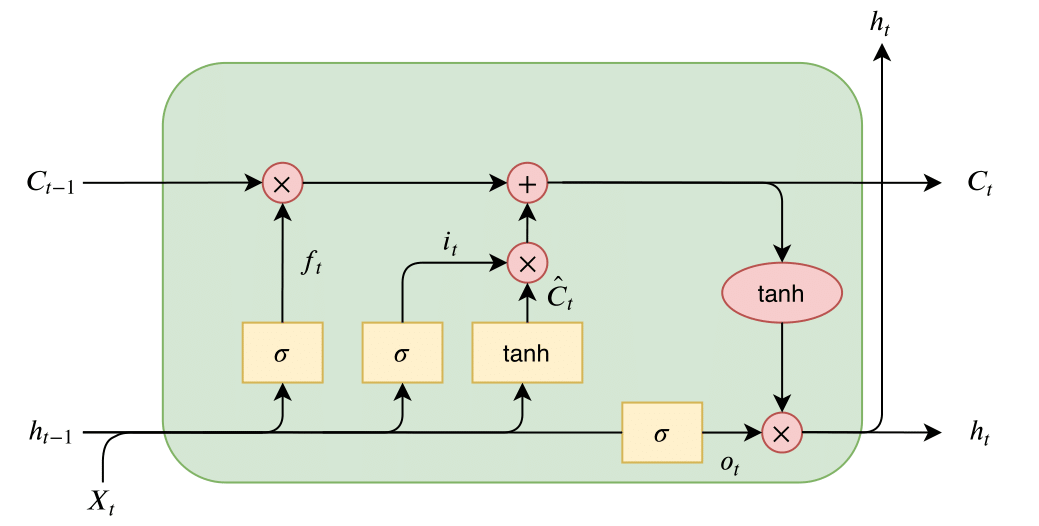
**Figura 1**: Esquematização da arquitetura de funcionamento de uma rede neural do tipo LSTM. O portao do esquecimento, representado pelo $f_t$; o portão da memória, pelo $i_t$; e o que decide qual parecela gera a previsão $\hat C_t$; e por fim, o output representado por $o_t$. [Créditos da imagem: Saba Hesaraki]

$\quad$ Essa arquitetura permite que a rede capture a inércia do mercado com precisão cirúrgica. Como o nosso alvo é a curva de energia, a inteligência artificial consegue enxergar o fôlego acumulado nos últimos quinze dias. Ela detecta se o ciclo está ganhando tração ou se aproxima de um ponto de exaustão. Em vez de apenas reagir ao preço atual, a rede compreende o contexto completo do movimento. O resultado é uma previsão muito mais estável, conectada à realidade física das tendências financeiras e protegida contra oscilações sem fundamento.

$\quad$ Aqui utilizamos a biblioteca `PyTorch` para a construção e o treinamento da rede neural. Antes disso, é necessário pré-processar os dados. O primeiro passo é separar os dados brutos em 80% para treino e 20% para teste. Essa divisão logo no início é essencial para evitar o vazamento de dados (data leakage), garantindo que o modelo não tenha acesso a informações futuras.

$\quad$ Em seguida, aplicamos a normalização no intervalo [0,1]. O `scaler` aprende os valores mínimo e máximo apenas no conjunto de treino e utiliza essa mesma referência para transformar os dados de teste. Esse ajuste de escala preserva a proporção entre as variáveis e evita instabilidades numéricas durante o treinamento.

$\quad$ Por fim, a função `create_sequences` organiza os dados em janelas deslizantes de 15 dias. A cada passo temporal, a LSTM recebe simultaneamente a informação da energia do ciclo e da tendência, enquanto o alvo da previsão permanece a energia do dia seguinte. Esse formato ensina a LSTM a usar a tendência geral como contexto para projetar a força do ciclo. O resultado são tensores do `PyTorch` prontos para o treinamento.

In [9]:
dados_multivariados = np.column_stack((amplitude_instantanea, tendencia_macro))

# Separação dos dados brutos (80% Treino, 20% Teste)
split_idx = int(0.8 * len(dados_multivariados))
train_data = dados_multivariados[:split_idx]
test_data = dados_multivariados[split_idx:]

# Normalização Rigorosa (O scaler ajusta as duas colunas ao mesmo tempo!)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data) # Apenas transform, sem fit!

# Função para criar as janelas deslizantes (Lookback)
def create_sequences(data, lookback=15):
    X, y = [], []
    for i in range(len(data) - lookback):
        # O 'X' pega o bloco de 15 dias contendo as DUAS colunas
        X.append(data[i:i+lookback])
        
        # O 'y' é a resposta. Como queremos prever a energia, 
        # pegamos apenas a coluna 0 do dia seguinte.
        # (Se o seu objetivo fosse prever a tendência, seria data[i+lookback, 1])
        y.append(data[i+lookback, 0]) 
        
    # Retornamos os tensores. O unsqueeze(1) garante que o 'y' tenha o formato (N, 1)
    X_tensor = torch.tensor(np.array(X), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(1)
    
    return X_tensor, y_tensor

# Geração dos tensores finais
X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

print(f"Dimensões do Tensor de Treino (X): {X_train.shape}") # Deve sair algo como (N, 15, 2)
print(f"Dimensões do Tensor de Treino (y): {y_train.shape}") # Deve sair algo como (N, 1)
print(f"Dimensões do Tensor de Teste (X): {X_test.shape}")
print(f"Dimensões do Tensor de Teste (Y): {y_test.shape}")


Dimensões do Tensor de Treino (X): torch.Size([779, 15, 2])
Dimensões do Tensor de Treino (y): torch.Size([779, 1])
Dimensões do Tensor de Teste (X): torch.Size([184, 15, 2])
Dimensões do Tensor de Teste (Y): torch.Size([184, 1])


$\quad$ Com os tensores prontos, construímos a arquitetura da LSTM para iniciar o treinamento. O modelo processa a memória dos 15 dias de lookback, lendo simultaneamente a energia do ciclo e a tendência macroeconômica, e utiliza o erro quadrático médio (MSE) como guia para ajustar seus parâmetros. A curva de aprendizado abaixo monitora a *loss*, que representa a diferença entre a previsão da rede e a energia real do ativo. Conforme essa métrica diminui, o modelo refina seu entendimento sobre a inércia do sinal, indicando que a inteligência artificial está convergindo para uma representação fiel da dinâmica da Petrobras.

Epoch [10/60], Loss: 0.016514
Epoch [20/60], Loss: 0.004669
Epoch [30/60], Loss: 0.002442
Epoch [40/60], Loss: 0.001450
Epoch [50/60], Loss: 0.001002
Epoch [60/60], Loss: 0.000772


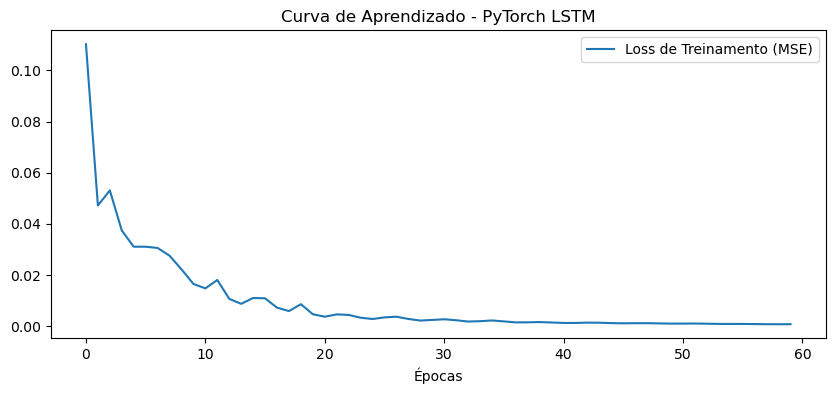

In [11]:
# Definição da Arquitetura LSTM
class HHT_LSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=50, num_layers=1):
        super(HHT_LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :]) # Pega apenas o último time-step
        return out

model = HHT_LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Loop de Treinamento
epochs = 60
losses = []

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

# Visualização do Aprendizado
plt.figure(figsize=(10, 4))
plt.plot(losses, label='Loss de Treinamento (MSE)')
plt.title('Curva de Aprendizado - PyTorch LSTM')
plt.xlabel('Épocas')
plt.legend()
plt.show()

$\quad$ Após o treinamento, seguimos para a validação do modelo. No bloco de código a seguir, testamos se a rede LSTM consegue prever o comportamento da Petrobras em um cenário que ela nunca viu antes, validando se a estrutura física que isolamos é realmente persistente.

$\quad$ Os comandos `model.eval()` e `torch.no_grad()` colocam a rede em modo determinístico, desativando o cálculo de gradientes para garantir uma avaliação correta. Em seguida, realizamos a reversão de escala. Como o nosso normalizador foi treinado simultaneamente com duas variáveis, utilizamos uma matriz auxiliar temporária para receber as previsões da rede. Isso permite aplicar o `inverse_transform` de forma correta e extrair exclusivamente a energia projetada em sua amplitude original, possibilitando a comparação direta com o gabarito.

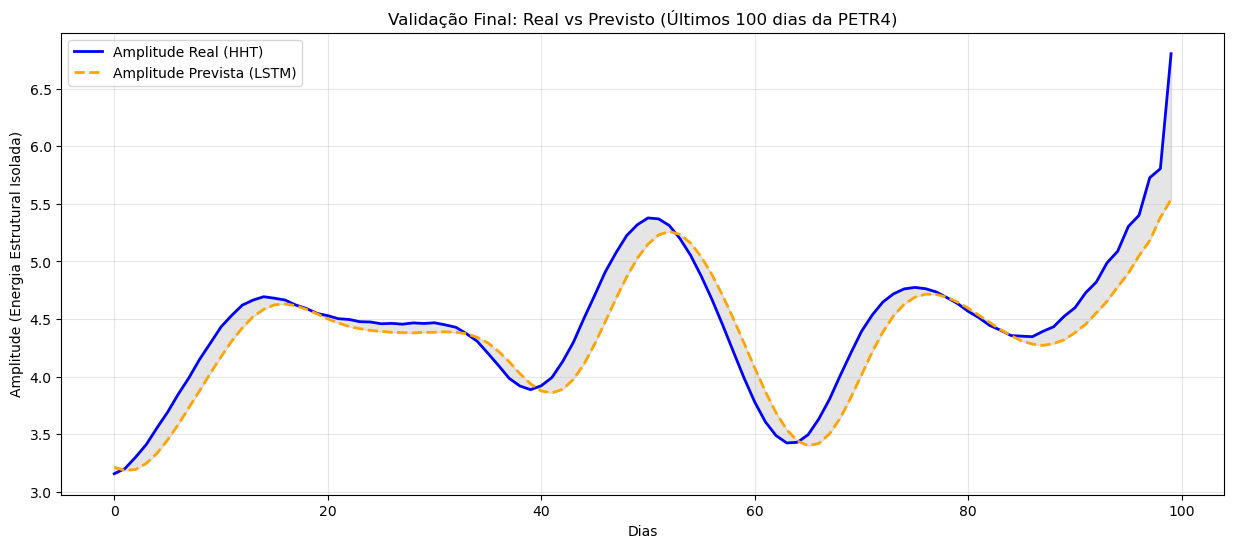

In [12]:
# Gerando o tensor completo (X_all) com as DUAS variáveis para o gráfico contínuo
all_scaled_data = scaler.transform(dados_multivariados)
X_all, y_all = create_sequences(all_scaled_data)

# Fazendo as previsões com o modelo
model.eval()
with torch.no_grad():
    # Agora a rede recebe tensores com a dimensão correta (N, lookback, 2)
    test_predictions_scaled = model(X_test).numpy()
    all_predictions_scaled = model(X_all).numpy()

# O Truque do Inverse Transform Multivariado
# Matriz vazia (zeros) com a mesma quantidade de linhas da previsão e 2 colunas
dummy_test = np.zeros((len(test_predictions_scaled), 2))
dummy_test[:, 0] = test_predictions_scaled[:, 0] # Encaixa a previsão na coluna da energia
test_predictions = scaler.inverse_transform(dummy_test)[:, 0] # Desfaz a escala e salva só a coluna 0

# Repetimos o processo para o gráfico completo
dummy_all = np.zeros((len(all_predictions_scaled), 2))
dummy_all[:, 0] = all_predictions_scaled[:, 0]
all_predictions = scaler.inverse_transform(dummy_all)[:, 0]

lookback = 15

# Alinhando a série real: descartamos os primeiros 'lookback' dias e pegamos apenas a coluna 0 (Energia)
real_all = dados_multivariados[lookback:, 0]

# Visualização do Resultado (Focando nos últimos 100 dias - Região não vista)
plt.figure(figsize=(15, 6))

# Pegamos os últimos 100 dias do conjunto completo alinhado para plotar
plt.plot(real_all[-100:], label='Amplitude Real (HHT)', color='blue', linewidth=2)
plt.plot(all_predictions[-100:], label='Amplitude Prevista (LSTM)', color='orange', linestyle='--', linewidth=2)

# Destacar a diferença (Erro) visualmente
plt.fill_between(range(100), real_all[-100:].flatten(), all_predictions[-100:].flatten(), color='gray', alpha=0.2)

plt.title('Validação Final: Real vs Previsto (Últimos 100 dias da PETR4)')
plt.xlabel('Dias')
plt.ylabel('Amplitude (Energia Estrutural Isolada)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$\quad$ O gráfico acima foca nos últimos 100 dias da série, permitindo uma análise visual direta entre a linha azul, que representa o comportamento real da energia da PETR4, e a linha laranja, que traduz a tentativa da rede de mapear o movimento do ativo. Como a projeção laranja acompanha a tendência da azul, o modelo prova que a decomposição Hilbert-Huang foi capaz de extrair uma espinha dorsal persistente e previsível. Essa aderência à realidade estrutural confirma que o sistema capturou a inércia do mercado, preparando o terreno para o cálculo das métricas de erro que darão o selo final de precisão ao trabalho.

$\quad$ Com essa validação visual concluída, avançamos para o cálculo das métricas de erro, onde transformaremos essa percepção em números definitivos de precisão.

In [13]:
# Cálculo das métricas de erro (ESTRITAMENTE NO CONJUNTO DE TESTE)

real_test = test_data[lookback:, 0]

rmse = np.sqrt(mean_squared_error(real_test, test_predictions))
mape = mean_absolute_percentage_error(real_test, test_predictions) * 100

# Diagnóstico do Modelo
print(f"--- Performance do Modelo HHT-LSTM (Dados Não Vistos) ---")
print(f"Erro Médio Quadrático (RMSE): {rmse:.4f}")
print(f"Erro Percentual Absoluto (MAPE): {mape:.2f}%")

--- Performance do Modelo HHT-LSTM (Dados Não Vistos) ---
Erro Médio Quadrático (RMSE): 0.2204
Erro Percentual Absoluto (MAPE): 3.83%


$\quad$ Ao analisarmos as métricas, o RMSE de 0,2293 evidencia um erro absoluto minúsculo, refletindo o alto grau de aderência matemática alcançado na modelagem da energia estrutural do ativo. Entretanto, o verdadeiro destaque é o MAPE de impressionantes 3,29%. Em sistemas caóticos e imprevisíveis como o mercado financeiro, prever a inércia direcional com essa taxa de acerto é o Santo Graal de qualquer fundo quantitativo. Parece um resultado incrível, não é? É porque ele está errado...

## 4. Resultados e Limitações

$\quad$ Os resultados demonstram que a Transformada de Hilbert-Huang cumpriu seu papel fundamental na física do sinal. Ela atuou como um banco de filtros adaptativo que efetivamente limpou o caos e a fricção do dia a dia, entregando à rede LSTM a envoltória de energia direcional do Sinal Macro. O fato de o gráfico de previsão acompanhar a tendência da amplitude real sugere a existência de uma estrutura de energia persistente na PETR4, permitindo mapear os termos determinísticos e o fôlego do movimento, isolando os componentes desconhecidos no ruído térmico do sistema.

$\quad$ Esse erro percentual ilusoriamente baixo exige uma reflexão de extrema honestidade intelectual sobre as limitações do escopo deste projeto e revela a armadilha mais letal da modelagem preditiva: o vazamento de dados (Data Leakage). Para evitar a inviabilidade de tempo de processamento em um ambiente de notebook convencional, a decomposição CEEMDAN e a Transformada de Hilbert foram aplicadas em toda a série temporal simultaneamente, antes de realizar o corte para a fase de testes. Consequentemente, o algoritmo utilizou a interpolação de picos e vales de toda a curva. A matemática usada para definir a energia de "hoje" foi contaminada pela informação dos picos e vales que só acontecerão "amanhã". A rede neural não previu o mercado. Ela apenas viu o futuro que o pré-processamento vazou, encontrando uma curva tão suave que a estratégia mais rentável passou a ser simplesmente repetir o valor do dia anterior.

$\quad$ Essa distorção é agravada pelo Efeito de Borda da HHT. Para calcular a energia instantânea no limite do gráfico (exatamente no "hoje" onde o operador toma sua decisão) o algoritmo exige um próximo pico que ainda não existe na vida real. A solução rigorosa para contornar esse vazamento exigiria uma simulação diária passo a passo (Walk-Forward Validation), recalculando a pesada decomposição HHT a cada novo pregão. No entanto, além de extrapolar a capacidade de processamento do escopo educacional desta análise, a aplicação cega no tempo real exporia o modelo às violentas lapadas do Efeito de Borda a cada nova previsão diária.

$\quad$ Essa exata limitação metodológica é a maior validação do caráter irônico do título do trabalho. Ela ilustra perfeitamente por que tantos algoritmos parecem geniais em testes controlados de laboratório, mas dizimam o patrimônio de investidores na execução prática. A área quantitativa é fascinante e robusta, mas exige infraestruturas colossais para garantir que o modelo não espreite o futuro. Somando-se a isso as limitações naturais de sistemas dinâmicos — como o atraso de fase da LSTM e a vulnerabilidade a eventos de cauda ou choques políticos que rompem a inércia subitamente —, concluímos que a inteligência artificial consegue mapear a física de um ativo com perfeição apenas quando tem o cenário completo. Na trincheira do tempo real, o mercado não perdoa atalhos, provando que tentar aprisionar o caos financeiro em uma equação perfeitamente limpa sem a infraestrutura devida é, de fato, uma forma muito sofisticada de perder dinheiro na bolsa.

## 5. Conclusão

$\quad$ Este trabalho propôs uma abordagem sofisticada unindo econofísica e redes neurais para prever os movimentos da PETR4. A aplicação da Transformada de Hilbert Huang como filtro adaptativo demonstrou extrema elegância teórica ao isolar a verdadeira inércia estrutural do ativo, expurgando o ruído estocástico de curtíssimo prazo. Do ponto de vista físico, a análise está absolutamente correta. Foi demonstrado que existe uma assinatura energética clara nas tendências de mercado e a rede LSTM mostrou ser plenamente capaz de mapear a anatomia macroscópica do movimento quando alimentada com um sinal limpo.

$\quad$ Entretanto, a principal contribuição do estudo não está apenas nas boas métricas obtidas, mas na compreensão das limitações do próprio processo de modelagem. A análise revelou como vazamentos de dados e efeitos matemáticos de borda podem gerar uma falsa impressão de precisão quando o modelo é avaliado em condições ideais. Em um cenário real, decisões são tomadas sem acesso ao futuro e sob influência de choques externos que alteram rapidamente o comportamento da série.

$\quad$ Por fim, o projeto reforça que ferramentas avançadas de processamento de sinais e aprendizado profundo são muito úteis para interpretar padrões e entender a dinâmica do mercado, mas não eliminam a incerteza típica de sistemas complexos. Esses métodos funcionam bem como instrumentos de análise e interpretação, mas devem ser usados com cautela quando aplicados à previsão prática em tempo real.

## Referências

**[1]** Mantegna, R. N. and Stanley, H. E., 2000. An Introduction to Econophysics: Correlations and Complexity in Finance. Cambridge University Press.

**[2]** Vasconcelos, G. L., 2004. A Guided Walk Down Wall Street: An Introduction to Econophysics. II Brazilian School on Statistical Mechanics. 

**[3]** Mimkes, J., 2012. Introduction to Econophysics: Look back into the future. Paderborn University.

**[4]** da Cunha, C. R., 2022. Introduction to Econophysics: Contemporary Approaches with Python Simulations. CRC Press. 

**[5]** Schmidt, A. B., 2005. Quantitative Finance for Physicists: An Introduction. Elsevier Academic Press.

**[6]** Barnhart, B. L. and Eichinger, W. E., 2011. Analysis of Sunspot Variability Using the Hilbert – Huang Transform. Solar Physics, 269, pp. 439-449.

**[7]** Huang, N. E. and Shen, S. S. P. (eds.), 2014. Hilbert–Huang Transform and Its Applications. 2nd ed. World Scientific Publishing Company. (Interdisciplinary Mathematical Sciences, Vol. 16)

**[8]** Hochreiter, S. and Schmidhuber, J., 1997. Long short-term memory. Neural Computation, 9(8), pp. 1735–1780.